## CS441: Applied ML - HW 1

### Part I: MNIST Classification

Include all the code for Part 1 in this section

In [5]:
# initialization code
import numpy as np
from tensorflow.keras.datasets import mnist
%matplotlib inline
from matplotlib import pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression

# loads MNIST data and reformat to 768-d vectors with values in range 0 to 1
# splits into train/val/test sets and provides indices for subsets of train
def load_mnist():
  (x_train, y_train), (x_test, y_test) = mnist.load_data()
  x_train = np.reshape(x_train, (len(x_train), 28*28))
  x_test = np.reshape(x_test, (len(x_test), 28*28))
  maxval = x_train.max()
  x_train = x_train/maxval
  x_test = x_test/maxval
  x_val = x_train[:10000]
  y_val = y_train[:10000]
  x_train = x_train[10000:]
  y_train = y_train[10000:]
  train_indices = dict()
  train_indices['xs'] = np.arange(50)
  train_indices['s'] = np.arange(500)
  train_indices['m'] = np.arange(5000)
  train_indices['all'] = np.arange(50000)
  return (x_train, y_train), (x_val, y_val), (x_test, y_test), train_indices

# displays a set of mnist images
def display_mnist(x, subplot_rows=1, subplot_cols=1):
  if subplot_rows>1 or subplot_cols>1:
    fig, ax = plt.subplots(subplot_rows, subplot_cols, figsize=(15,15))
    for i in np.arange(len(x)):
      ax[i].imshow(np.reshape(x[i], (28,28)), cmap='gray')
      ax[i].axis('off')
  else:
      plt.imshow(np.reshape(x, (28,28)), cmap='gray')
      plt.axis('off')
  plt.show()

# counts the number of examples per class
def class_count_mnist(y):
  count = np.zeros((10,),dtype='uint32')
  for i in np.arange(10):
    count[i] = sum(y==i)
  return count

In [4]:
# example of using MNIST load, display, indices, and count functions
(x_train, y_train), (x_val, y_val), (x_test, y_test), train_indices = load_mnist()
display_mnist(x_train[:10],1,10)
print('Total size: train={}, val={}, test ={}'.format(len(x_train), len(x_val), len(x_test)))
print('Train subset size: xs={}, s={}, m={}, all={}'.format(len(train_indices['xs']),len(train_indices['s']),len(train_indices['m']),len(train_indices['all'])))
print('Class count for s: {}'.format(class_count_mnist(y_train[train_indices['s']])))

Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz: None -- [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1091)

In [308]:
#Importing the required modules
from scipy.stats import mode
 
#Euclidean Distance
def eucledian(p1,p2):
    dist = np.sqrt(np.sum((p1-p2)**2))
    return dist
 
#Function to calculate KNN
def knn(x_train, y_train, x_test, k):
    op_labels = []
     
    #Loop through the Datapoints to be classified
    for item in x_test: 
         
        #Array to store distances
        point_dist = []
         
        #Loop through each training Data
        for j in range(len(x_train)): 
            distances = eucledian(np.array(x_train[j,:]) , item) 
            #Calculating the distance
            point_dist.append(distances) 
        point_dist = np.array(point_dist) 
         
        #Sorting the array while preserving the index
        #Keeping the first K datapoints
        dist = np.argsort(point_dist)[:k] 
         
        #Labels of the K datapoints from above
        labels = y_train[dist]
         
        #Majority voting
        lab = mode(labels) 
        lab = lab.mode[0]
        op_labels.append(lab)
 
    return op_labels

In [314]:
%%time
y_pred = knn(x_train, y_train, x_test[1], 1)
y_pred

KeyboardInterrupt: ignored

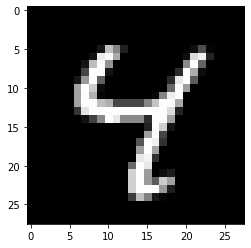

In [262]:
plt.imshow(x_test[6].reshape(28, 28), cmap = "gray");

In [ ]:
# This is a suggested function definition for training Naive Bayes, but feel free to change it
def train_NB_mnist(X, y, alpha=1):
  '''
  Train P(x_f=v|y=c) for each feature f, value v, and class c.  Can assume 10 classes and that the features are binary variables 
  Input: X[i] is the ith training data. y[i] is the ith training label. alpha is the count prior
  Output: return pxy of shape (Nf, 10, 2), where Nf is the number of features; pxy[f,c,v] is P(x_f=v|y=c) 
  '''
  # needs code here

  return pxy

# This is a suggested function definition for evauating Naive Bayes, but feel free to change it
def eval_NB_mnist(pxy, X):
  '''
  Evaluate naive bayes for mnist
  Input: pxy is the trained model; X is the test data
  Output: return y_pred, where y_pred[i] is the predicted ith test label  
  '''

  # needs code here

  return y_pred



In [150]:
# don't forget logistic regression!
logistic = LogisticRegression()

In [165]:
logistic.fit(x_train, y_train)

/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [166]:
logistic.predict(x_test)

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [164]:
# Use score method to get accuracy of model
score = logistic.score(x_test, y_test)
print(score)

0.9263


In [ ]:
# experiments code

## Part 2: Temperature Regression

Include all your code for part 2 in this section.  You can copy-paste code from part 1 if it is re-usable.

In [302]:
import numpy as np
from google.colab import drive
%matplotlib inline
from matplotlib import pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# load data (modify to match your data directory or comment)
def load_temp_data():
  drive.mount('/content/drive')
  datadir = "/content/drive/My Drive/CS441/hw1/" 
  T = np.load(datadir + 'temperature_data.npz')
  x_train, y_train, x_val, y_val, x_test, y_test, dates_train, dates_val, dates_test, feature_to_city, feature_to_day = \
  T['x_train'], T['y_train'], T['x_val'], T['y_val'], T['x_test'], T['y_test'], T['dates_train'], T['dates_val'], T['dates_test'], T['feature_to_city'], T['feature_to_day']
  return (x_train, y_train, x_val, y_val, x_test, y_test, dates_train, dates_val, dates_test, feature_to_city, feature_to_day)

# plot one data point for listed cities and target temperature
def plot_temps(x, y, cities, feature_to_city, feature_to_day, target_date):
  nc = len(cities)
  ndays = 5
  xplot = np.array([-5,-4,-3,-2,-1])
  yplot = np.zeros((nc,ndays))
  for f in np.arange(len(x)):
    for c in np.arange(nc):
      if cities[c]==feature_to_city[f]:
        yplot[feature_to_day[f]+ndays,c] = x[f]
  plt.plot(xplot,yplot)
  plt.legend(cities)
  plt.plot(0, y, 'b*', markersize=10)
  plt.title('Predict Temp for Cleveland on ' + target_date)
  plt.xlabel('Day')
  plt.ylabel('Avg Temp (C)')
  plt.show()




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Feature 361: city = Cleveland, day= -1
Baseline - predict same as previous day: RMSE=3.460601246750482, MAE=1.3964240043768943


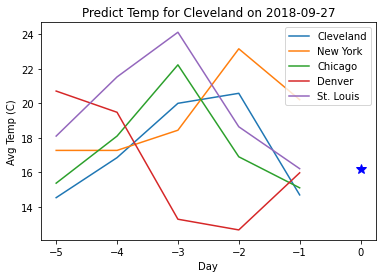

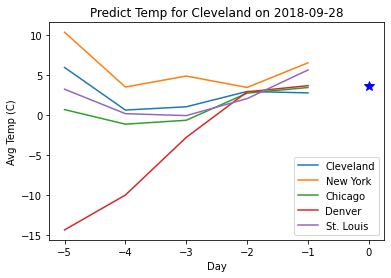

In [303]:
# load data (may need to modify file location in preceding cell)
(x_train, y_train, x_val, y_val, x_test, y_test, dates_train, dates_val, dates_test, feature_to_city, feature_to_day) = load_temp_data()

# example of displaying information related to a feature index
f = 361
print('Feature {}: city = {}, day= {}'.format(f,feature_to_city[f], feature_to_day[f]))

# example of computing RMSE and median absolute error (for baseline of predicting based on previous day's temperature in Cleveland)
baseline_rmse = np.sqrt(np.mean((y_val[1:]-y_val[:-1])**2)) # root mean squared error
baseline_mae = np.sqrt(np.median(np.abs(y_val[1:]-y_val[:-1]))) # median absolute error
print('Baseline - predict same as previous day: RMSE={}, MAE={}'.format(baseline_rmse, baseline_mae))

# plots temperatures for preceding days for given cities, and target (Cleveland) temp
plot_temps(x_val[0], y_val[0], ['Cleveland', 'New York', 'Chicago', 'Denver', 'St. Louis'], feature_to_city, feature_to_day, dates_val[0])
plot_temps(x_val[100], y_val[100], ['Cleveland', 'New York', 'Chicago', 'Denver', 'St. Louis'], feature_to_city, feature_to_day, dates_val[1])

In [304]:
#Importing the required modules
from scipy.stats import mode
 
#Euclidean Distance
def eucledian(p1,p2):
    dist = np.sqrt(np.sum((p1-p2)**2))
    return dist
 
#Function to calculate KNN
def knn(x_train, y_train, x_test, k):
    op_labels = []
     
    #Loop through the Datapoints to be classified
    for item in x_test: 
         
        #Array to store distances
        point_dist = []
         
        #Loop through each training Data
        for j in range(len(x_train)): 
            distances = eucledian(np.array(x_train[j,:]) , item) 
            #Calculating the distance
            point_dist.append(distances) 
        point_dist = np.array(point_dist) 
         
        #Sorting the array while preserving the index
        #Keeping the first K datapoints
        dist = np.argsort(point_dist)[:k] 
         
        #Labels of the K datapoints from above
        labels = y_train[dist]
         
        #Majority voting
        lab = mode(labels) 
        lab = lab.mode[0]
        op_labels.append(lab)
 
    return op_labels

In [305]:
%%time
y_pred = knn(x_train, y_train, x_test, 3)
y_pred

CPU times: user 8.7 s, sys: 458 ms, total: 9.16 s
Wall time: 8.76 s


[18.18,
 22.05,
 17.67,
 15.24,
 22.48,
 22.48,
 12.01,
 10.95,
 10.95,
 18.46,
 9.54,
 10.53,
 10.53,
 16.26,
 10.34,
 7.58,
 7.49,
 2.91,
 5.57,
 5.57,
 9.02,
 9.49,
 9.49,
 9.49,
 7.8,
 11.04,
 8.46,
 8.86,
 5.57,
 7.83,
 5.57,
 5.57,
 5.57,
 7.83,
 1.85,
 -1.29,
 -0.46,
 3.12,
 -0.04,
 -0.04,
 -0.04,
 -0.09,
 -0.09,
 2.31,
 7.08,
 5.13,
 -5.54,
 -4.13,
 0.72,
 -8.18,
 2.95,
 3.29,
 0.76,
 2.81,
 -2.81,
 6.06,
 1.37,
 -5.54,
 2.64,
 -3.1,
 8.57,
 11.08,
 -0.34,
 -2.95,
 -1.11,
 -0.99,
 -4.92,
 -2.14,
 -3.04,
 -2.45,
 -3.82,
 -2.92,
 -2.89,
 0.92,
 -7.72,
 -11.35,
 -3.99,
 -1.03,
 -2.83,
 -4.65,
 -8.36,
 -2.77,
 -2.81,
 -11.82,
 0.87,
 -3.88,
 0.08,
 -4.66,
 -2.47,
 0.01,
 2.54,
 3.25,
 3.25,
 2.06,
 -1.5,
 -2.08,
 -2.14,
 3.06,
 2.16,
 -0.14,
 -2.95,
 -1.45,
 3.33,
 -3.75,
 0.99,
 -2.45,
 -0.14,
 0.86,
 -5.38,
 3.12,
 4.51,
 3.56,
 -10.54,
 -9.13,
 -0.99,
 -12.66,
 -11.14,
 -3.88,
 -5.2,
 -1.06,
 -0.1,
 -2.47,
 -1.45,
 -0.56,
 -0.56,
 -1.45,
 -0.56,
 -7.31,
 6.09,
 6.35,
 0.57,
 -1.

In [218]:
# Don't forget linear regression!
Ridge = Ridge()

In [ ]:
Ridge.fit(x_train, y_train)

In [ ]:
y_pred = Ridge.predict(x_test)
y_pred

In [ ]:
score = Ridge.score(x_test, y_test)
print(score)

In [ ]:
rmse = np.sqrt(np.mean((y_pred-y_val)**2))
rmse

In [ ]:
mae = np.sqrt(np.median(np.abs(y_pred-y_val)))
mae

In [234]:
# Feature analysis
Lasso = Lasso()

In [ ]:
Lasso.fit(x_train, y_train)

In [ ]:
Lasso.predict(x_test)

In [ ]:
score = Lasso.score(x_test, y_test)
print(score)

## Part 3: Stretch Goals
Include all your code used for part 3 in this section. You can copy-paste code from parts 1 or 2 if it is re-usable.